**ROI V2**

Configuring GPU settings...
✓ GPU configured: 1 device(s) available

             MOBILENET-UNET V2: HIGH-RES ROI + CLAHE + BOUNDARY LOSS + POST-PROCESSING              

V2 Improvements:
  1. HIGH-RES ROI: Original resolution (~2000x2000) → crop → 512x512
     (V1 was: 512x512 → crop → upscale = blurry)
  2. CLAHE preprocessing for better disc/cup contrast
  3. Boundary-aware + Soft Dice loss for disc-cup edge accuracy
  4. Morphological post-processing (largest component + anatomical constraints)
  5. Test-time augmentation (4 flipped passes averaged)
  6. Enhanced augmentation (GridDistortion, CoarseDropout, CLAHE)
  7. Tighter ROI padding: 1.2x (was 1.5x)
  8. Cosine decay LR schedule for smoother convergence

Architecture:
  - MobileNetV2 Encoder + Deeper Decoder
  - MSCA + LBFR + PPM (12 attention modules)
  - Combined loss: Focal + EIoU + Soft Dice + Boundary-aware
  - MC Dropout (15 forward passes)

Glaucoma Scoring: CDR-based (Normal/Suspect/Moderate/Critical)

LOADING DATA WI

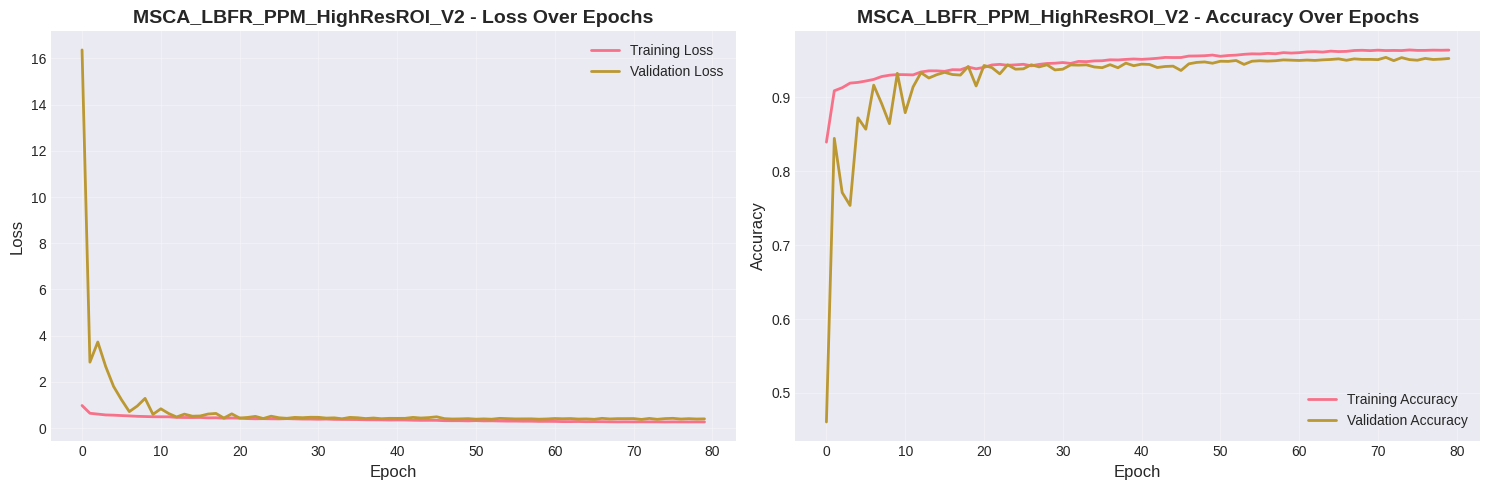


EVALUATION: MSCA+LBFR+PPM+HighResROI+V2
  Running test-time augmentation (4 passes)...
  Applying morphological post-processing...

Saving all 400 test predictions to results/MSCA+LBFR+PPM+HighResROI+V2_all_preds...
  Processed 50/400
  Processed 100/400
  Processed 150/400
  Processed 200/400
  Processed 250/400
  Processed 300/400
  Processed 350/400
  Processed 400/400
✓ Saved comparison masks to results/MSCA+LBFR+PPM+HighResROI+V2_all_preds
  ✓ Saved: results/MSCA+LBFR+PPM+HighResROI+V2_confusion_matrices.png


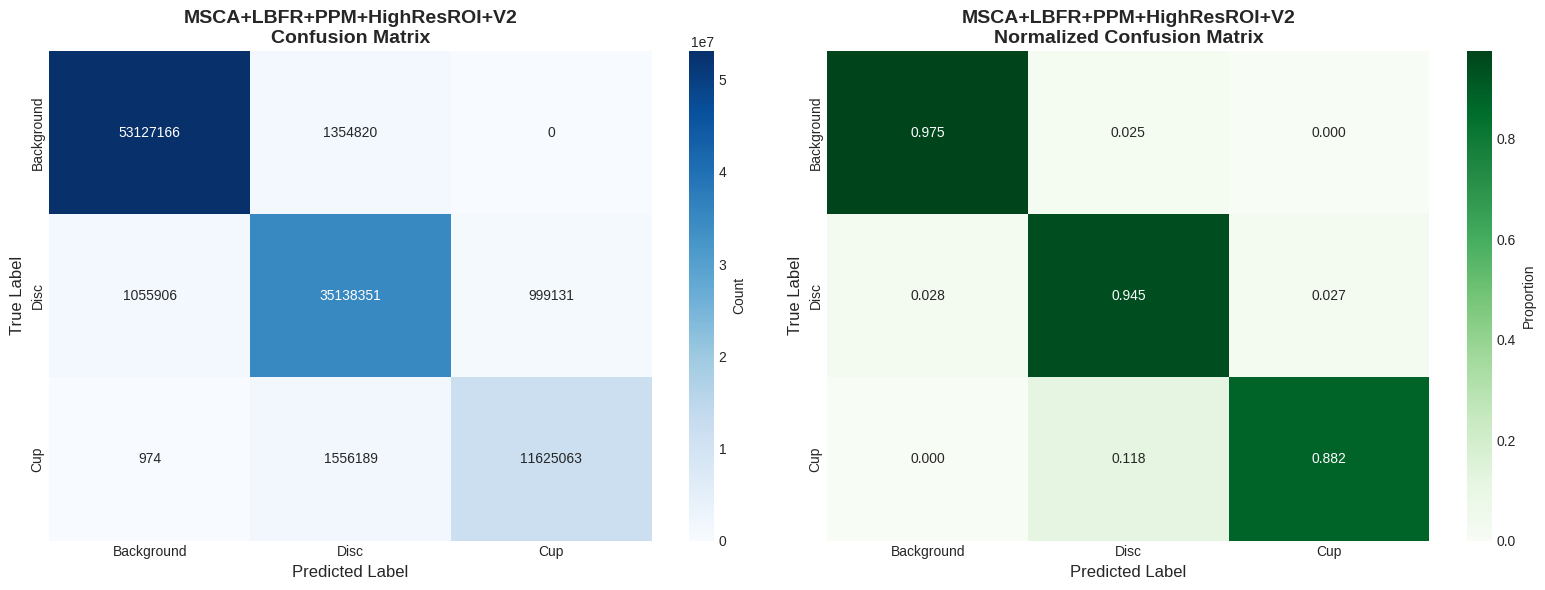


Confusion Matrix:
[[53127166  1354820        0]
 [ 1055906 35138351   999131]
 [     974  1556189 11625063]]

Normalized Confusion Matrix:
[[0.975 0.025 0.   ]
 [0.028 0.945 0.027]
 [0.    0.118 0.882]]

Precision, Recall, F1 Score per class (ROI-level):
  Background: Precision=0.9805, Recall=0.9751, F1=0.9778
  Disc: Precision=0.9235, Recall=0.9447, F1=0.9340
  Cup: Precision=0.9209, Recall=0.8819, F1=0.9009

Macro-averaged metrics:
  Precision: 0.9416
  Recall: 0.9339
  F1 Score: 0.9376
  Background: Dice=0.9778, IoU=0.9566
  Disc: Dice=0.9340, IoU=0.8762
  Cup: Dice=0.9009, IoU=0.8197

GLAUCOMA PROGRESSION ANALYSIS (Area-based CDR)

--------------------------------------------------------------------------------
CDR Statistics:
--------------------------------------------------------------------------------
  Mean GT CDR:   0.5982 ± 0.1781
  Mean Pred CDR: 0.5769 ± 0.1559
  Mean CDR Error: 0.0573 ± 0.0602

PROGRESSION CLASSIFICATION ACCURACY

Overall Accuracy: 81.75%
  - Correctly 

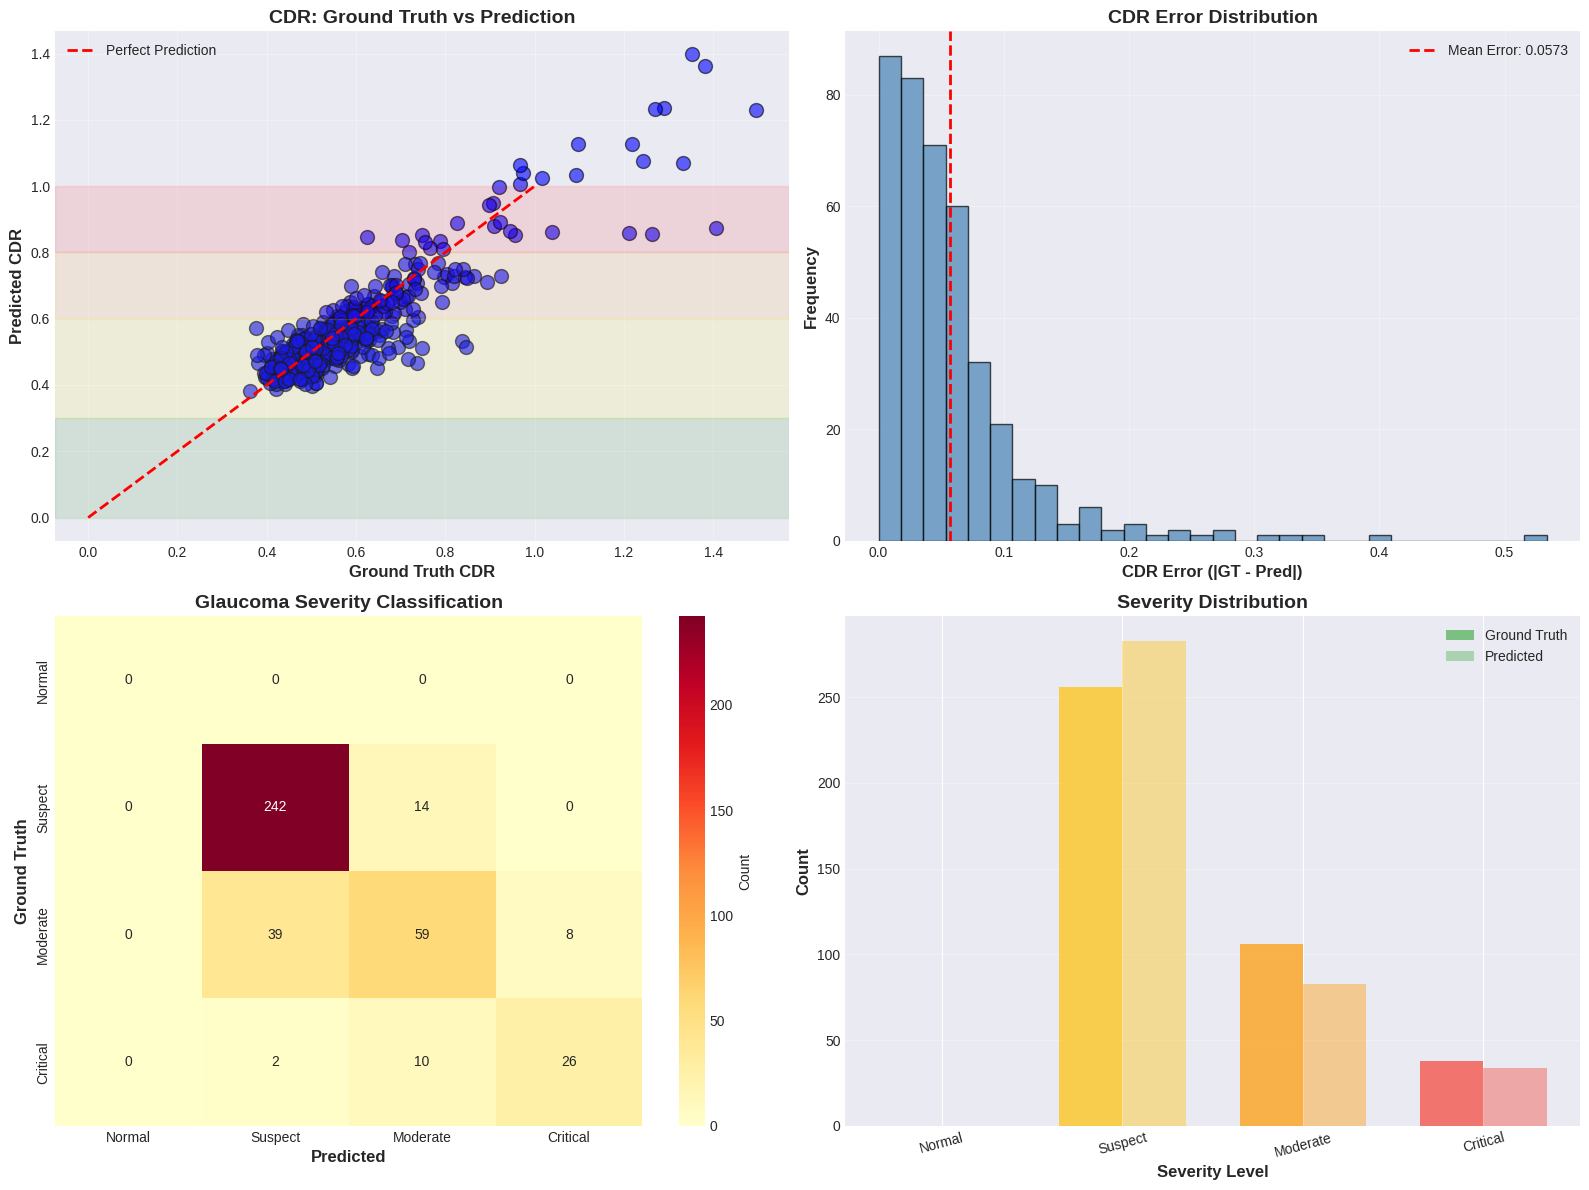

  ✓ Saved: results/MSCA+LBFR+PPM+HighResROI+V2_predictions_cdr.png


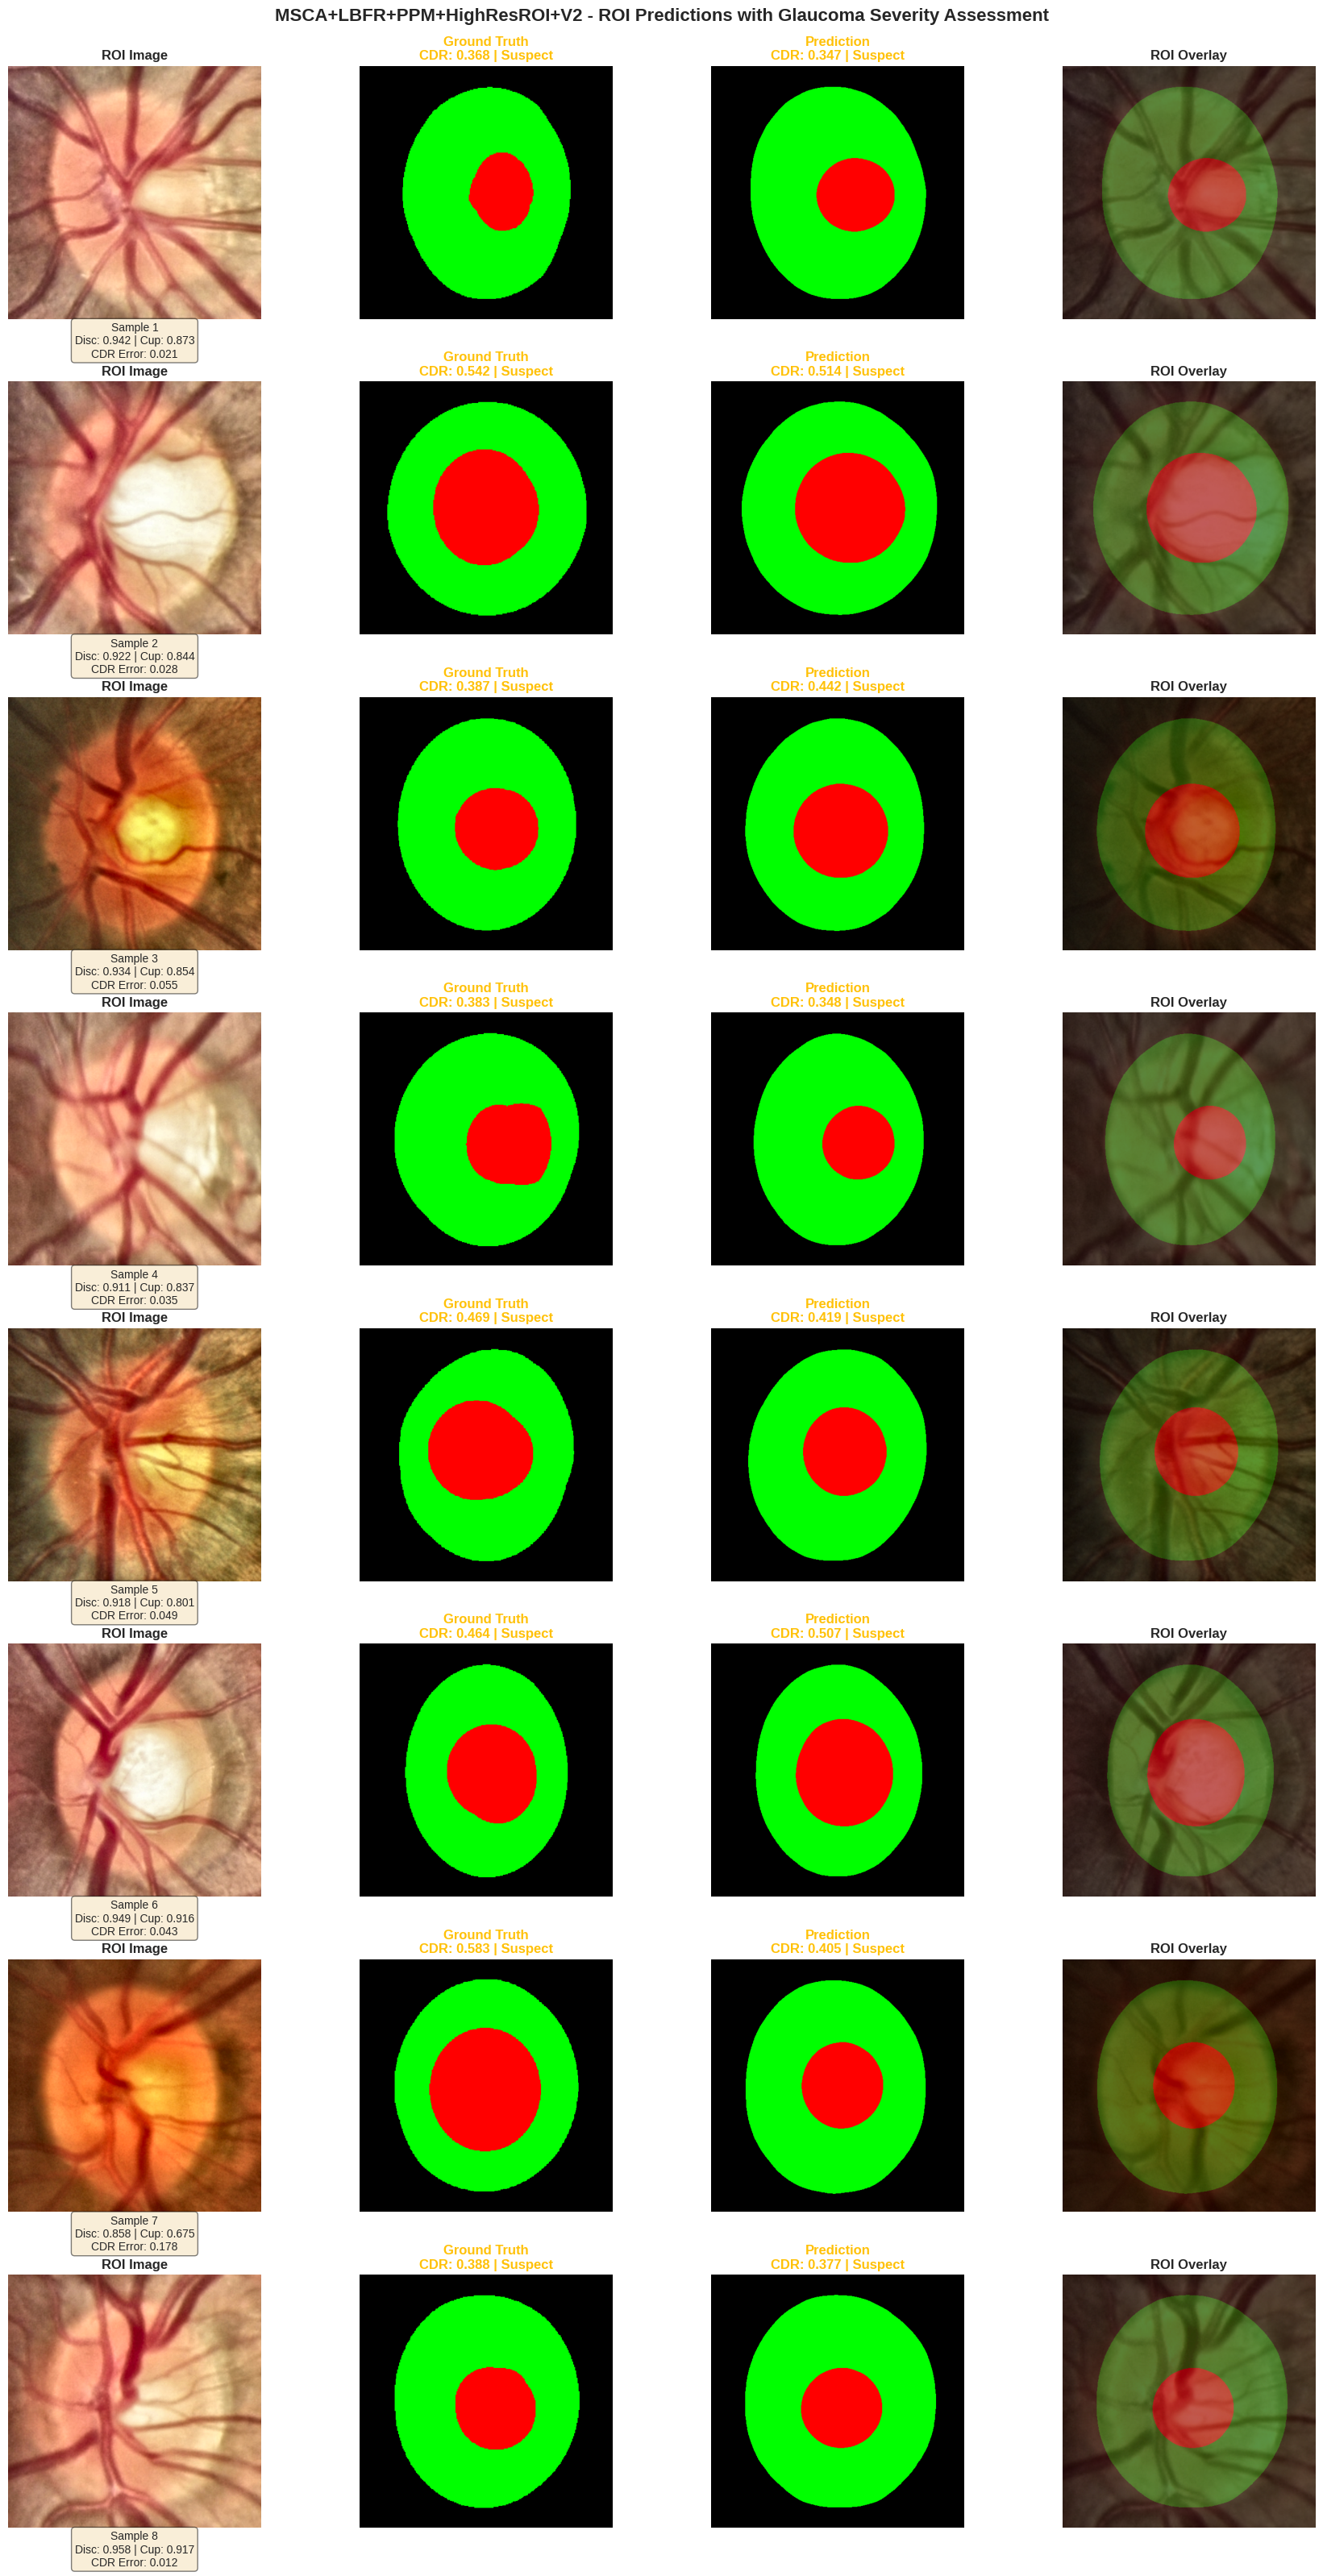


MC DROPOUT UNCERTAINTY ESTIMATION

Running MC Dropout with 15 stochastic forward passes...
  Completed: 5/15 forward passes
  Completed: 10/15 forward passes
  Completed: 15/15 forward passes
✓ MC Dropout completed
  Background uncertainty: 0.0018
  Disc uncertainty: 0.0029
  Cup uncertainty: 0.0012

                              ✓ V2 TRAINING AND EVALUATION COMPLETED!                               

Model: MSCA + LBFR + PPM + High-Res ROI + Focal + EIoU + Dice + Boundary + MC Dropout
Parameters: 47,631,627
ROI: High-res extraction, Padding=1.2x, Size=(512, 512)
Post-processing: Morphological + Anatomical constraints
TTA: 4-pass flip averaging
Results saved in: results/




In [ ]:
"""
MOBILENET-UNET V2: HIGH-RES ROI + CLAHE + BOUNDARY LOSS + POST-PROCESSING
===========================================================================
Key improvements over V1:
  1. HIGH-RES ROI: Load at original resolution (~2000x2000), crop ROI, resize to 512x512
     V1 Bug: loaded at 512x512 first, then cropped ROI → blurry upscaled junk
  2. CLAHE: Contrast-Limited Adaptive Histogram Equalization for better disc/cup edges
  3. BOUNDARY-AWARE + DICE LOSS: Penalizes errors at disc-cup boundary where CDR depends
  4. MORPHOLOGICAL POST-PROCESSING: Connected components + anatomical constraints
  5. TEST-TIME AUGMENTATION (TTA): Average flipped predictions for robustness
  6. ENHANCED AUGMENTATION: GridDistortion, CoarseDropout, CLAHE added
  7. TIGHTER ROI: 1.2x padding (was 1.5x) for more focused disc/cup

Architecture:
  - MobileNetV2 Encoder + Deeper Decoder with skip connections
  - MSCA + LBFR + PPM triple attention on each decoder block (12 modules)
  - Combined loss: Focal + EIoU + Soft Dice
  - MC Dropout for uncertainty estimation
  - CDR-based glaucoma severity classification
"""

import os
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, backend as K
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from PIL import Image
import cv2
from scipy import ndimage

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# GPU CONFIGURATION
# ============================================================================

def configure_gpu():
    """Configure GPU settings for optimal performance"""
    print("Configuring GPU settings...")
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        try:
            for device in physical_devices:
                tf.config.experimental.set_memory_growth(device, True)
            print(f"✓ GPU configured: {len(physical_devices)} device(s) available")
            return True
        except RuntimeError as e:
            print(f"GPU configuration error: {e}")
            return False
    else:
        print("⚠ No GPU detected, running on CPU")
        return False

# ============================================================================
# CLAHE PREPROCESSING (NEW)
# ============================================================================

def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Apply CLAHE to enhance local contrast in fundus images.
    Applied on L channel of LAB color space for illumination-independent enhancement.
    Significantly improves visibility of disc-cup boundaries.
    """
    img_uint8 = (np.clip(image, 0, 1) * 255).astype(np.uint8)
    lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return enhanced.astype(np.float32) / 255.0

# ============================================================================
# ROI EXTRACTION
# ============================================================================

def find_disc_region(mask, disc_class=1, cup_class=2):
    """Find bounding box center and radius of the optic disc+cup region."""
    roi_mask = ((mask == disc_class) | (mask == cup_class)).astype(np.uint8)
    if roi_mask.sum() == 0:
        return None
    coords = np.where(roi_mask > 0)
    y_min, y_max = coords[0].min(), coords[0].max()
    x_min, x_max = coords[1].min(), coords[1].max()
    center_y = (y_min + y_max) // 2
    center_x = (x_min + x_max) // 2
    radius = max(y_max - y_min, x_max - x_min) // 2
    return center_y, center_x, radius

def extract_roi(image, mask, padding_factor=1.2, roi_size=(512, 512)):
    """
    Extract ROI around the optic disc. Crops square region centered on disc
    with padding, then resizes to roi_size.
    """
    result = find_disc_region(mask)
    if result is None:
        h, w = image.shape[:2]
        return image.copy(), mask.copy(), (0, 0, h, w)
    
    center_y, center_x, radius = result
    h, w = image.shape[:2]
    roi_half = max(int(radius * padding_factor), 60)
    
    y1 = max(0, center_y - roi_half)
    y2 = min(h, center_y + roi_half)
    x1 = max(0, center_x - roi_half)
    x2 = min(w, center_x + roi_half)
    
    # Make square
    crop_h, crop_w = y2 - y1, x2 - x1
    if crop_h > crop_w:
        diff = crop_h - crop_w
        x1 = max(0, x1 - diff // 2)
        x2 = min(w, x1 + crop_h)
        x1 = max(0, x2 - crop_h)
    elif crop_w > crop_h:
        diff = crop_w - crop_h
        y1 = max(0, y1 - diff // 2)
        y2 = min(h, y1 + crop_w)
        y1 = max(0, y2 - crop_w)
    
    roi_image = image[y1:y2, x1:x2]
    roi_mask = mask[y1:y2, x1:x2]
    
    roi_image_resized = np.array(Image.fromarray(
        (roi_image * 255).astype(np.uint8)).resize(roi_size, Image.BILINEAR)) / 255.0
    roi_mask_resized = np.array(Image.fromarray(
        roi_mask).resize(roi_size, Image.NEAREST))
    
    return roi_image_resized.astype(np.float32), roi_mask_resized.astype(np.uint8), (y1, x1, y2, x2)

def map_roi_prediction_to_full(pred_mask_roi, roi_coords, full_size=(512, 512)):
    """Map ROI prediction back to full image coordinates."""
    y1, x1, y2, x2 = roi_coords
    pred_resized = np.array(Image.fromarray(
        pred_mask_roi.astype(np.uint8)).resize((x2 - x1, y2 - y1), Image.NEAREST))
    full_mask = np.zeros(full_size, dtype=np.uint8)
    full_mask[y1:y2, x1:x2] = pred_resized
    return full_mask

# ============================================================================
# HIGH-RESOLUTION ROI LOADING (KEY IMPROVEMENT)
# ============================================================================

def load_all_data_with_highres_roi(root_dir, roi_size=(512, 512), padding_factor=1.2):
    """
    Load images at ORIGINAL resolution, extract ROI, resize to roi_size.
    
    KEY FIX: V1 loaded images at 512x512 first, then cropped ROI from the
    already-downsampled image. A ~200x200 crop from 512x512, upscaled to 512x512 
    = BLURRY, detail-lost input. The model gains nothing from ROI.
    
    V2: Load at original resolution (~2000x2000), crop ROI (~600x600 real pixels),
    resize to 512x512. The model gets SHARP, high-resolution disc/cup detail.
    Memory efficient: only one full-res image in memory at a time.
    """
    all_roi_images, all_roi_masks, all_full_masks_512 = [], [], []
    
    for split in ["train", "val", "test"]:
        images_folder = os.path.join(root_dir, split, "Images")
        masks_folder = os.path.join(root_dir, split, "Masks")
        image_files = sorted(os.listdir(images_folder))
        mask_files = sorted(os.listdir(masks_folder))
        mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}
        
        count = 0
        for img_file in image_files:
            img_name = os.path.splitext(img_file)[0]
            if img_name not in mask_dict:
                continue
            
            # Load at ORIGINAL resolution — this is the key change
            img_highres = np.array(Image.open(
                os.path.join(images_folder, img_file))) / 255.0
            mask_highres = np.array(Image.open(
                os.path.join(masks_folder, mask_dict[img_name])))
            
            # Extract ROI from HIGH-RES image
            roi_img, roi_msk, _ = extract_roi(
                img_highres, mask_highres, padding_factor, roi_size)
            
            # Apply CLAHE enhancement on the ROI
            roi_img = apply_clahe(roi_img)
            
            all_roi_images.append(roi_img)
            all_roi_masks.append(roi_msk)
            
            # Save 512x512 full mask for CDR evaluation
            full_msk_512 = np.array(Image.fromarray(
                mask_highres).resize((512, 512), Image.NEAREST))
            all_full_masks_512.append(full_msk_512)
            
            # Free high-res data immediately
            del img_highres, mask_highres
            count += 1
        
        print(f"  {split}: {count} samples (original resolution → ROI extracted)")
    
    return (np.array(all_roi_images, dtype=np.float32),
            np.array(all_roi_masks, dtype=np.uint8),
            np.array(all_full_masks_512, dtype=np.uint8))

def create_new_split_roi(roi_images, roi_masks, full_masks_512):
    """Create split: 600 train, 200 val, 400 test — same random_state=42"""
    indices = np.arange(len(roi_images))
    idx_temp, idx_test = train_test_split(indices, test_size=400, random_state=42)
    idx_train, idx_val = train_test_split(idx_temp, test_size=200, random_state=42)
    
    print(f"Split - Train: {len(idx_train)}, Val: {len(idx_val)}, Test: {len(idx_test)}")
    return (
        (roi_images[idx_train], roi_masks[idx_train]),
        (roi_images[idx_val], roi_masks[idx_val]),
        (roi_images[idx_test], roi_masks[idx_test]),
        full_masks_512[idx_test]
    )

# ============================================================================
# DATA AUGMENTATION (ENHANCED)
# ============================================================================

def setup_augmentations():
    return A.Compose([
        # Geometric (stronger for ROI crops)
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.15, rotate_limit=25,
                           border_mode=0, p=0.7),
        A.ElasticTransform(alpha=40, sigma=6, p=0.3),
        A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.2),
        # Colour (enhanced for fundus)
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.7),
        A.HueSaturationValue(hue_shift_limit=12, sat_shift_limit=25, val_shift_limit=15, p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.3),
        A.RandomGamma(gamma_limit=(75, 125), p=0.3),
        A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=0.3),
        # CoarseDropout removed — too aggressive for small cup region
    ])

def data_generator(images, masks, batch_size, augment=None):
    idxs = np.arange(len(images))
    while True:
        np.random.shuffle(idxs)
        for i in range(0, len(images), batch_size):
            batch_idxs = idxs[i:i+batch_size]
            batch_x, batch_y = [], []
            for idx in batch_idxs:
                img, mask = images[idx], masks[idx]
                if augment:
                    aug = augment(image=img, mask=mask)
                    img_aug, mask_aug = aug['image'], aug['mask']
                else:
                    img_aug, mask_aug = img, mask
                mask_cat = to_categorical(mask_aug, num_classes=3)
                batch_x.append(img_aug)
                batch_y.append(mask_cat)
            yield np.stack(batch_x).astype(np.float32), np.stack(batch_y).astype(np.float32)

# ============================================================================
# MSCA MODULE (FROM ODFORMER)
# ============================================================================

def msca_block(x, channels, dilation_rates=[1, 2, 3, 5], block_name='msca'):
    """
    Multi-scale Context Aggregator (MSCA) from ODFormer
    Multi-scale feature extraction using dilated convolutions with residual connection.
    """
    multi_scale_features = []
    filters_per_branch = channels // len(dilation_rates)
    
    for i, rate in enumerate(dilation_rates):
        branch = layers.Conv2D(
            filters_per_branch, (3, 3), padding='same', dilation_rate=rate,
            use_bias=False, name=f'{block_name}_dil{rate}_conv')(x)
        branch = layers.BatchNormalization(name=f'{block_name}_dil{rate}_bn')(branch)
        branch = layers.Activation('relu', name=f'{block_name}_dil{rate}_relu')(branch)
        multi_scale_features.append(branch)
    
    concat = layers.Concatenate(name=f'{block_name}_concat')(multi_scale_features)
    fused = layers.Conv2D(channels, (1, 1), use_bias=False, name=f'{block_name}_fusion')(concat)
    fused = layers.BatchNormalization(name=f'{block_name}_fusion_bn')(fused)
    fused = layers.Activation('relu', name=f'{block_name}_fusion_relu')(fused)
    output = layers.Add(name=f'{block_name}_residual')([x, fused])
    return output

# ============================================================================
# LBFR MODULE (FROM ODFORMER)
# ============================================================================

def lbfr_block(x, channels, reduction=16, block_name='lbfr'):
    """
    Lightweight Bidirectional Feature Recalibrator (LBFR) from ODFormer
    Channel attention (avg+max pooling) + Spatial attention + Recalibration.
    """
    # Channel Attention
    avg_pool = layers.GlobalAveragePooling2D(name=f'{block_name}_avg_pool')(x)
    avg_pool = layers.Reshape((1, 1, channels), name=f'{block_name}_avg_reshape')(avg_pool)
    max_pool = layers.GlobalMaxPooling2D(name=f'{block_name}_max_pool')(x)
    max_pool = layers.Reshape((1, 1, channels), name=f'{block_name}_max_reshape')(max_pool)
    
    fc1 = layers.Conv2D(channels // reduction, (1, 1), use_bias=False, name=f'{block_name}_fc1')
    fc2 = layers.Conv2D(channels, (1, 1), use_bias=False, name=f'{block_name}_fc2')
    
    avg_out = fc2(layers.Activation('relu', name=f'{block_name}_fc1_relu_avg')(fc1(avg_pool)))
    max_out = fc2(layers.Activation('relu', name=f'{block_name}_fc1_relu_max')(fc1(max_pool)))
    
    channel_att = layers.Activation('sigmoid', name=f'{block_name}_channel_sigmoid')(
        layers.Add(name=f'{block_name}_channel_add')([avg_out, max_out]))
    x_channel = layers.Multiply(name=f'{block_name}_channel_multiply')([x, channel_att])
    
    # Spatial Attention
    avg_spatial = layers.Lambda(lambda x: K.mean(x, axis=-1, keepdims=True),
                                name=f'{block_name}_spatial_avg')(x_channel)
    max_spatial = layers.Lambda(lambda x: K.max(x, axis=-1, keepdims=True),
                                name=f'{block_name}_spatial_max')(x_channel)
    spatial_concat = layers.Concatenate(name=f'{block_name}_spatial_concat')([avg_spatial, max_spatial])
    spatial_att = layers.Activation('sigmoid', name=f'{block_name}_spatial_sigmoid')(
        layers.Conv2D(1, (7, 7), padding='same', use_bias=False,
                      name=f'{block_name}_spatial_conv')(spatial_concat))
    x_spatial = layers.Multiply(name=f'{block_name}_spatial_multiply')([x_channel, spatial_att])
    
    # Recalibration
    recalibrated = layers.Conv2D(channels, (1, 1), use_bias=False,
                                 name=f'{block_name}_recalibrate')(x_spatial)
    recalibrated = layers.BatchNormalization(name=f'{block_name}_recalibrate_bn')(recalibrated)
    output = layers.Add(name=f'{block_name}_residual')([x, recalibrated])
    return output

# ============================================================================
# PPM MODULE (FROM PSPNET/ODFORMER)
# ============================================================================

def ppm_block(x, channels, pool_scales=[1, 2, 3, 6], block_name='ppm'):
    """
    Pyramid Pooling Module (PPM) from PSPNet
    Multi-scale adaptive pooling at scales: 1x1, 2x2, 3x3, 6x6
    """
    h, w = x.shape[1], x.shape[2]
    ppm_features = [x]
    filters_per_scale = channels // len(pool_scales)
    
    for i, scale in enumerate(pool_scales):
        pool_h = max(h // scale, 1)
        pool_w = max(w // scale, 1)
        
        pooled = layers.AveragePooling2D(
            pool_size=(h // pool_h, w // pool_w),
            strides=(h // pool_h, w // pool_w),
            name=f'{block_name}pool{scale}x{scale}')(x)
        conv = layers.Conv2D(filters_per_scale, (1, 1), use_bias=False,
                             name=f'{block_name}conv{scale}x{scale}')(pooled)
        conv = layers.BatchNormalization(name=f'{block_name}bn{scale}x{scale}')(conv)
        conv = layers.Activation('relu', name=f'{block_name}relu{scale}x{scale}')(conv)
        upsampled = layers.Resizing(h, w, interpolation='bilinear',
                                    name=f'{block_name}upsample{scale}x{scale}')(conv)
        ppm_features.append(upsampled)
    
    concat = layers.Concatenate(name=f'{block_name}_concat')(ppm_features)
    fused = layers.Conv2D(channels, (3, 3), padding='same', use_bias=False,
                          name=f'{block_name}_fusion')(concat)
    fused = layers.BatchNormalization(name=f'{block_name}_fusion_bn')(fused)
    fused = layers.Activation('relu', name=f'{block_name}_fusion_relu')(fused)
    return fused

# ============================================================================
# LOSS FUNCTIONS (ENHANCED)
# ============================================================================

def focal_loss(y_true, y_pred, gamma=2.0, alpha=None, epsilon=1e-7):
    if alpha is None:
        alpha = [0.25, 1.0, 1.0]
    y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
    focal_loss_value = 0.0
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        bce = -(y_true_c * K.log(y_pred_c) + (1 - y_true_c) * K.log(1 - y_pred_c))
        pt = y_true_c * y_pred_c + (1 - y_true_c) * (1 - y_pred_c)
        focal_weight = K.pow(1 - pt, gamma)
        focal_loss_value += alpha[c] * K.mean(focal_weight * bce)
    return focal_loss_value

def enhanced_iou_loss(y_true, y_pred, smooth=1e-7):
    eiou_loss_value = 0.0
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        
        intersection = K.sum(y_true_c * y_pred_c, axis=[1, 2])
        union = K.sum(y_true_c, axis=[1, 2]) + K.sum(y_pred_c, axis=[1, 2]) - intersection
        iou = (intersection + smooth) / (union + smooth)
        
        binary_true = K.cast(y_true_c > 0.5, 'float32')
        binary_pred = K.cast(y_pred_c > 0.5, 'float32')

        _h = tf.cast(tf.shape(y_true_c)[1], 'float32')
        _w = tf.cast(tf.shape(y_true_c)[2], 'float32')
        row_coords = tf.reshape(tf.range(tf.shape(y_true_c)[1], dtype=tf.float32) / _h, [1, -1, 1])
        col_coords = tf.reshape(tf.range(tf.shape(y_true_c)[2], dtype=tf.float32) / _w, [1, 1, -1])

        rp_t = K.max(binary_true, axis=2, keepdims=True)
        rp_p = K.max(binary_pred, axis=2, keepdims=True)
        cp_t = K.max(binary_true, axis=1, keepdims=True)
        cp_p = K.max(binary_pred, axis=1, keepdims=True)

        y_min_t = K.min(row_coords + (1.0 - rp_t), axis=[1, 2])
        y_max_t = K.max(row_coords * rp_t, axis=[1, 2])
        x_min_t = K.min(col_coords + (1.0 - cp_t), axis=[1, 2])
        x_max_t = K.max(col_coords * cp_t, axis=[1, 2])

        y_min_p = K.min(row_coords + (1.0 - rp_p), axis=[1, 2])
        y_max_p = K.max(row_coords * rp_p, axis=[1, 2])
        x_min_p = K.min(col_coords + (1.0 - cp_p), axis=[1, 2])
        x_max_p = K.max(col_coords * cp_p, axis=[1, 2])

        y_true_bbox = K.stack([y_min_t, x_min_t, y_max_t, x_max_t], axis=-1)
        y_pred_bbox = K.stack([y_min_p, x_min_p, y_max_p, x_max_p], axis=-1)
        
        center_true = K.stack([
            (y_true_bbox[:, 0] + y_true_bbox[:, 2]) / 2.0,
            (y_true_bbox[:, 1] + y_true_bbox[:, 3]) / 2.0
        ], axis=-1)
        center_pred = K.stack([
            (y_pred_bbox[:, 0] + y_pred_bbox[:, 2]) / 2.0,
            (y_pred_bbox[:, 1] + y_pred_bbox[:, 3]) / 2.0
        ], axis=-1)
        
        center_distance = K.sum(K.square(center_true - center_pred), axis=-1)
        diag_length = K.square(y_true_bbox[:, 2] - y_true_bbox[:, 0]) + \
                     K.square(y_true_bbox[:, 3] - y_true_bbox[:, 1])
        diag_length = K.maximum(diag_length, 1e-7)
        
        eiou = iou - (center_distance / diag_length)
        eiou_loss_value += K.mean(1.0 - eiou)
    
    return eiou_loss_value / 3.0

def soft_dice_loss(y_true, y_pred, smooth=1e-7):
    """Soft Dice loss — directly optimizes the Dice coefficient metric."""
    dice_loss_value = 0.0
    # Weight disc and cup more than background
    class_weights = [0.5, 1.5, 2.0]
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        intersection = K.sum(y_true_c * y_pred_c, axis=[1, 2])
        union = K.sum(y_true_c, axis=[1, 2]) + K.sum(y_pred_c, axis=[1, 2])
        dice = (2. * intersection + smooth) / (union + smooth)
        dice_loss_value += class_weights[c] * K.mean(1.0 - dice)
    return dice_loss_value / sum(class_weights)

def boundary_aware_loss(y_true, y_pred, boundary_weight=3.0, dilation_size=5):
    """
    Boundary-aware loss: extra penalty at disc-cup boundary pixels.
    The disc-cup boundary is exactly where CDR accuracy depends.
    """
    epsilon = 1e-7
    y_pred_clip = K.clip(y_pred, epsilon, 1.0 - epsilon)
    # Per-pixel cross-entropy
    ce = -K.sum(y_true * K.log(y_pred_clip), axis=-1)  # [batch, H, W]
    
    # Compute boundary from GT disc and cup edges
    y_true_disc = y_true[:, :, :, 1]
    y_true_cup = y_true[:, :, :, 2]
    
    disc_dy = y_true_disc[:, 1:, :] - y_true_disc[:, :-1, :]
    disc_dx = y_true_disc[:, :, 1:] - y_true_disc[:, :, :-1]
    cup_dy = y_true_cup[:, 1:, :] - y_true_cup[:, :-1, :]
    cup_dx = y_true_cup[:, :, 1:] - y_true_cup[:, :, :-1]
    
    disc_grad = K.sqrt(
        K.square(tf.pad(disc_dy, [[0,0],[0,1],[0,0]])) +
        K.square(tf.pad(disc_dx, [[0,0],[0,0],[0,1]])))
    cup_grad = K.sqrt(
        K.square(tf.pad(cup_dy, [[0,0],[0,1],[0,0]])) +
        K.square(tf.pad(cup_dx, [[0,0],[0,0],[0,1]])))
    
    boundary_mask = K.clip(disc_grad + cup_grad, 0, 1)
    # Dilate boundary to create a wider attention zone
    boundary_4d = K.expand_dims(boundary_mask, axis=-1)
    boundary_dilated = tf.nn.max_pool2d(
        boundary_4d, ksize=dilation_size, strides=1, padding='SAME')
    boundary_dilated = K.squeeze(boundary_dilated, axis=-1)
    
    # Weight map: 1.0 everywhere, up to boundary_weight at boundaries
    weight_map = 1.0 + (boundary_weight - 1.0) * boundary_dilated
    return K.mean(weight_map * ce)

def focal_eiou_combined_loss(y_true, y_pred):
    """Combined loss: Focal + EIoU + Soft Dice"""
    fl = focal_loss(y_true, y_pred, gamma=2.0, alpha=[0.25, 1.0, 1.0])
    eiou = enhanced_iou_loss(y_true, y_pred)
    dl = soft_dice_loss(y_true, y_pred)
    return fl + eiou + 0.5 * dl
# ============================================================================

def enhanced_decoder_block_with_triple_attention(x, skip_connection, filters, block_name, dropout_rate=0.3):
    """
    Enhanced decoder block with MSCA + LBFR + PPM triple attention.
    Sequential: Conv → MSCA → LBFR → PPM
    """
    x = layers.UpSampling2D((2, 2), name=f'{block_name}_upsample')(x)
    
    if skip_connection.shape[-1] != x.shape[-1]:
        skip_connection = layers.Conv2D(x.shape[-1], (1, 1), padding='same',
                                       name=f'{block_name}_skip_adjust')(skip_connection)
    
    x = layers.Concatenate(name=f'{block_name}_concat')([x, skip_connection])
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv1')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.Dropout(dropout_rate, name=f'{block_name}_dropout')(x)
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv3')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn3')(x)
    
    residual = x
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv4')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn4')(x)
    
    x = layers.Add(name=f'{block_name}_residual')([x, residual])
    x = layers.Conv2D(filters, (1, 1), activation='relu', padding='same', name=f'{block_name}_conv_final')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn_final')(x)
    
    x = msca_block(x, filters, dilation_rates=[1, 2, 3, 5], block_name=f'{block_name}_msca')
    x = lbfr_block(x, filters, reduction=16, block_name=f'{block_name}_lbfr')
    x = ppm_block(x, filters, pool_scales=[1, 2, 3, 6], block_name=f'{block_name}_ppm')
    
    return x

def build_unet_with_triple_attention(input_shape=(512, 512, 3), num_classes=3, dropout_rate=0.3):
    """Build MobileNetV2-UNet with MSCA + LBFR + PPM triple attention"""
    inputs = layers.Input(input_shape, dtype='float32')
    backbone = MobileNetV2(input_tensor=inputs, weights='imagenet', include_top=False)
    
    skip_1 = backbone.get_layer('block_1_expand_relu').output   # 256x256
    skip_2 = backbone.get_layer('block_3_expand_relu').output   # 128x128
    skip_3 = backbone.get_layer('block_6_expand_relu').output   # 64x64
    skip_4 = backbone.get_layer('block_13_expand_relu').output  # 32x32
    bridge = backbone.output  # 16x16
    
    bridge = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(bridge)
    bridge = layers.BatchNormalization()(bridge)
    bridge = layers.Dropout(dropout_rate, name='bridge_dropout')(bridge)
    
    x = enhanced_decoder_block_with_triple_attention(bridge, skip_4, 512, 'decoder_1', dropout_rate)
    x = enhanced_decoder_block_with_triple_attention(x, skip_3, 256, 'decoder_2', dropout_rate)
    x = enhanced_decoder_block_with_triple_attention(x, skip_2, 128, 'decoder_3', dropout_rate * 0.7)
    x = enhanced_decoder_block_with_triple_attention(x, skip_1, 64, 'decoder_4', dropout_rate * 0.5)
    
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax', dtype='float32')(x)
    
    model = models.Model(inputs, outputs)
    
    print(f"\nModel Configuration:")
    print(f"  Total Parameters: {model.count_params():,}")
    print(f"  Triple Attention: MSCA + LBFR + PPM per decoder block")
    print(f"  Total Attention Blocks: 12 (4 MSCA + 4 LBFR + 4 PPM)")
    
    return model

# ============================================================================
# METRICS
# ============================================================================

def dice_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    return (2. * intersection + smooth) / (K.sum(y_true_class) + K.sum(y_pred_class) + smooth)

def dice_class_0(y_true, y_pred): return dice_coef_class(y_true, y_pred, 0)
def dice_class_1(y_true, y_pred): return dice_coef_class(y_true, y_pred, 1)
def dice_class_2(y_true, y_pred): return dice_coef_class(y_true, y_pred, 2)

def iou_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    union = K.sum(y_true_class) + K.sum(y_pred_class) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_class_0(y_true, y_pred): return iou_coef_class(y_true, y_pred, 0)
def iou_class_1(y_true, y_pred): return iou_coef_class(y_true, y_pred, 1)
def iou_class_2(y_true, y_pred): return iou_coef_class(y_true, y_pred, 2)

def mc_dropout_predict(model, X, num_samples=15, batch_size=4, verbose=True):
    """MC Dropout prediction for uncertainty estimation"""
    if verbose:
        print(f"\nRunning MC Dropout with {num_samples} stochastic forward passes...")
    
    sum_preds = None
    sum_sq_preds = None
    num_batches = int(np.ceil(len(X) / batch_size))
    
    for i in range(num_samples):
        if verbose and (i + 1) % 5 == 0:
            print(f"  Completed: {i+1}/{num_samples} forward passes")
        
        batch_preds = []
        for batch_idx in range(num_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, len(X))
            pred_batch = model(X[start_idx:end_idx], training=True)
            batch_preds.append(pred_batch.numpy())
        
        current_pass_preds = np.concatenate(batch_preds, axis=0)
        
        if sum_preds is None:
            sum_preds = current_pass_preds.astype(np.float32)
            sum_sq_preds = np.square(current_pass_preds).astype(np.float32)
        else:
            sum_preds += current_pass_preds
            sum_sq_preds += np.square(current_pass_preds)
        
        del current_pass_preds, batch_preds
        if (i + 1) % 5 == 0:
            gc.collect()
    
    mean_pred = sum_preds / num_samples
    var_pred = np.maximum(sum_sq_preds / num_samples - np.square(mean_pred), 0)
    std_pred = np.sqrt(var_pred)
    
    del sum_preds, sum_sq_preds
    gc.collect()
    
    if verbose:
        print(f"✓ MC Dropout completed")
    return mean_pred, std_pred

# ============================================================================
# POST-PROCESSING (NEW)
# ============================================================================

def postprocess_prediction(pred_mask, min_disc_size=100):
    """
    Morphological post-processing to clean up predictions.
    1. Keep largest connected component for disc and cup
    2. Morphological closing to fill holes, opening to remove noise
    3. Anatomical constraint: cup must be inside disc
    """
    result = np.zeros_like(pred_mask, dtype=np.uint8)
    
    # Process disc region (disc + cup combined for outer boundary)
    disc_region = ((pred_mask == 1) | (pred_mask == 2)).astype(np.uint8)
    if disc_region.sum() > min_disc_size:
        labeled, num_features = ndimage.label(disc_region)
        if num_features > 1:
            sizes = ndimage.sum(disc_region, labeled, range(1, num_features + 1))
            largest = np.argmax(sizes) + 1
            disc_region = (labeled == largest).astype(np.uint8)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        disc_region = cv2.morphologyEx(disc_region, cv2.MORPH_CLOSE, kernel)
        disc_region = cv2.morphologyEx(disc_region, cv2.MORPH_OPEN, kernel)
    
    # Process cup
    cup_mask = (pred_mask == 2).astype(np.uint8)
    if cup_mask.sum() > 30:
        labeled, num_features = ndimage.label(cup_mask)
        if num_features > 1:
            sizes = ndimage.sum(cup_mask, labeled, range(1, num_features + 1))
            largest = np.argmax(sizes) + 1
            cup_mask = (labeled == largest).astype(np.uint8)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        cup_mask = cv2.morphologyEx(cup_mask, cv2.MORPH_CLOSE, kernel)
        cup_mask = cv2.morphologyEx(cup_mask, cv2.MORPH_OPEN, kernel)
        # Anatomical constraint: cup must be inside disc
        cup_mask = cup_mask & disc_region
    
    result[disc_region > 0] = 1
    result[cup_mask > 0] = 2
    return result

def postprocess_batch(pred_masks):
    """Apply post-processing to a batch of predictions."""
    return np.array([postprocess_prediction(m) for m in pred_masks], dtype=np.uint8)

# ============================================================================
# TEST-TIME AUGMENTATION (NEW)
# ============================================================================

def predict_with_tta(model, images, batch_size=4):
    """
    Test-time augmentation: average predictions over original + flips.
    Produces more robust, smoother predictions.
    """
    preds = model.predict(images, batch_size=batch_size, verbose=0)
    
    # Horizontal flip
    preds_h = model.predict(images[:, :, ::-1, :], batch_size=batch_size, verbose=0)[:, :, ::-1, :]
    
    # Vertical flip
    preds_v = model.predict(images[:, ::-1, :, :], batch_size=batch_size, verbose=0)[:, ::-1, :, :]
    
    # Both flips
    preds_hv = model.predict(images[:, ::-1, ::-1, :], batch_size=batch_size, verbose=0)[:, ::-1, ::-1, :]
    
    return (preds + preds_h + preds_v + preds_hv) / 4.0

# ============================================================================
# GLAUCOMA PROGRESSION SCORING
# ============================================================================

def calculate_cdr(mask, disc_class=1, cup_class=2, method='vertical'):
    """Calculate Cup-to-Disc Ratio (CDR) from segmentation mask"""
    disc_mask = (mask == disc_class).astype(np.uint8)
    cup_mask = (mask == cup_class).astype(np.uint8)
    
    disc_area = disc_mask.sum()
    cup_area = cup_mask.sum()
    
    if disc_area == 0 or cup_area == 0:
        return {'vCDR': 0.0, 'hCDR': 0.0, 'avgCDR': 0.0, 'area_CDR': 0.0, 'valid': False,
                'method': method, 'disc_area': 0, 'cup_area': 0}
    
    disc_coords = np.where(disc_mask > 0)
    cup_coords = np.where(cup_mask > 0)
    
    disc_v_diameter = disc_coords[0].max() - disc_coords[0].min() + 1
    cup_v_diameter = cup_coords[0].max() - cup_coords[0].min() + 1
    disc_h_diameter = disc_coords[1].max() - disc_coords[1].min() + 1
    cup_h_diameter = cup_coords[1].max() - cup_coords[1].min() + 1
    
    vCDR = cup_v_diameter / disc_v_diameter if disc_v_diameter > 0 else 0.0
    hCDR = cup_h_diameter / disc_h_diameter if disc_h_diameter > 0 else 0.0
    area_CDR = np.sqrt(cup_area / disc_area)
    
    if method == 'vertical':
        avgCDR = vCDR
    elif method == 'area_sqrt':
        avgCDR = area_CDR
    else:
        avgCDR = (vCDR + hCDR) / 2.0
    
    return {
        'vCDR': float(vCDR), 'hCDR': float(hCDR),
        'avgCDR': float(avgCDR), 'area_CDR': float(area_CDR),
        'valid': True, 'method': method,
        'disc_area': int(disc_area), 'cup_area': int(cup_area),
        'disc_v_diameter': int(disc_v_diameter), 'cup_v_diameter': int(cup_v_diameter)
    }

def classify_glaucoma_severity(cdr):
    """Classify glaucoma severity based on CDR"""
    if cdr < 0.3:
        return 0, 'Normal', '#4CAF50'
    elif cdr < 0.6:
        return 1, 'Suspect', '#FFC107'
    elif cdr < 0.8:
        return 2, 'Moderate', '#FF9800'
    else:
        return 3, 'Critical', '#F44336'

def analyze_glaucoma_progression(masks, predictions, cdr_method='area_sqrt'):
    """Analyze glaucoma progression for a batch of samples"""
    results = []
    for i, (gt_mask, pred_mask) in enumerate(zip(masks, predictions)):
        gt_cdr = calculate_cdr(gt_mask, method=cdr_method)
        pred_cdr = calculate_cdr(pred_mask, method=cdr_method)
        
        if gt_cdr['valid']:
            gt_class, gt_label, gt_color = classify_glaucoma_severity(gt_cdr['avgCDR'])
        else:
            gt_class, gt_label, gt_color = -1, 'Invalid', '#9E9E9E'
        
        if pred_cdr['valid']:
            pred_class, pred_label, pred_color = classify_glaucoma_severity(pred_cdr['avgCDR'])
        else:
            pred_class, pred_label, pred_color = -1, 'Invalid', '#9E9E9E'
        
        cdr_error = abs(gt_cdr['avgCDR'] - pred_cdr['avgCDR']) if gt_cdr['valid'] and pred_cdr['valid'] else np.nan
        severity_match = (gt_label == pred_label)
        manual_review = (gt_label == 'Critical') or (not severity_match)
        
        results.append({
            'Sample': i + 1,
            'GT_vCDR': gt_cdr['vCDR'], 'GT_hCDR': gt_cdr['hCDR'],
            'GT_avgCDR': gt_cdr['avgCDR'], 'GT_area_CDR': gt_cdr['area_CDR'],
            'GT_Severity': gt_label,
            'Pred_vCDR': pred_cdr['vCDR'], 'Pred_hCDR': pred_cdr['hCDR'],
            'Pred_avgCDR': pred_cdr['avgCDR'], 'Pred_area_CDR': pred_cdr['area_CDR'],
            'Pred_Severity': pred_label,
            'CDR_Error': cdr_error, 'Severity_Match': severity_match,
            'Manual_Review_Needed': manual_review
        })
    return pd.DataFrame(results)

def calculate_progression_accuracy(df_progression):
    """Calculate simple accuracy metrics: GT severity vs Predicted severity"""
    results = {}
    total = len(df_progression)
    correct = df_progression['Severity_Match'].sum()
    results['overall'] = {'total': total, 'correct': correct, 'accuracy': (correct / total) * 100}
    
    severity_classes = ['Normal', 'Suspect', 'Moderate', 'Critical']
    results['per_class'] = {}
    for severity in severity_classes:
        gt_count = len(df_progression[df_progression['GT_Severity'] == severity])
        pred_count = len(df_progression[df_progression['Pred_Severity'] == severity])
        correct_count = len(df_progression[
            (df_progression['GT_Severity'] == severity) &
            (df_progression['Pred_Severity'] == severity)])
        results['per_class'][severity] = {
            'gt_count': gt_count, 'pred_count': pred_count,
            'correct': correct_count,
            'accuracy': (correct_count / gt_count * 100) if gt_count > 0 else 0.0
        }
    
    manual_review_needed = df_progression['Manual_Review_Needed'].sum()
    results['manual_review'] = {
        'count': manual_review_needed,
        'percentage': (manual_review_needed / total) * 100
    }
    return results

# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_training_history(history, model_name, save_dir='results'):
    """Plot training history - Loss and Accuracy"""
    os.makedirs(save_dir, exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title(f'{model_name} - Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title(f'{model_name} - Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{save_dir}/{model_name}_history.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_history.png")
    plt.show()
    plt.close()

def plot_confusion_matrices(y_true, y_pred, model_name, save_dir='results'):
    """Plot confusion matrices"""
    os.makedirs(save_dir, exist_ok=True)
    
    y_true_labels = np.argmax(y_true, axis=-1).flatten()
    y_pred_labels = np.argmax(y_pred, axis=-1).flatten()
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    class_names = ['Background', 'Disc', 'Cup']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    
    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], cbar_kws={'label': 'Proportion'})
    axes[1].set_title(f'{model_name}\nNormalized Confusion Matrix', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12)
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_confusion_matrices.png", dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_confusion_matrices.png")
    plt.show()
    plt.close()
    
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nNormalized Confusion Matrix:\n{np.round(cm_normalized, 3)}")
    return cm, cm_normalized

def plot_sample_predictions_with_cdr(model, X_test_roi, y_test_roi,
                                     model_name, num_samples=6, save_dir='results'):
    """Visualize predictions with CDR and glaucoma severity"""
    os.makedirs(save_dir, exist_ok=True)
    
    # Use TTA for visualization predictions
    y_pred = predict_with_tta(model, X_test_roi[:num_samples], batch_size=4)
    y_pred_labels = np.argmax(y_pred, axis=-1)
    y_pred_labels = postprocess_batch(y_pred_labels)
    
    colors = {0: [0, 0, 0], 1: [0, 255, 0], 2: [255, 0, 0]}
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(18, 4*num_samples))
    
    for i in range(num_samples):
        # ROI image
        axes[i, 0].imshow(X_test_roi[i])
        axes[i, 0].set_title('ROI Image', fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Ground truth on ROI
        gt_mask = y_test_roi[i]
        gt_colored = np.zeros((*gt_mask.shape, 3), dtype=np.uint8)
        for class_id, color in colors.items():
            gt_colored[gt_mask == class_id] = color
        
        gt_cdr = calculate_cdr(gt_mask)
        gt_label = classify_glaucoma_severity(gt_cdr['avgCDR'])[1] if gt_cdr['valid'] else 'Invalid'
        gt_color = classify_glaucoma_severity(gt_cdr['avgCDR'])[2] if gt_cdr['valid'] else '#9E9E9E'
        
        axes[i, 1].imshow(gt_colored)
        axes[i, 1].set_title(f'Ground Truth\nCDR: {gt_cdr["avgCDR"]:.3f} | {gt_label}',
                            fontsize=12, fontweight='bold', color=gt_color)
        axes[i, 1].axis('off')
        
        # Prediction on ROI
        pred_colored = np.zeros((*y_pred_labels[i].shape, 3), dtype=np.uint8)
        for class_id, color in colors.items():
            pred_colored[y_pred_labels[i] == class_id] = color
        
        pred_cdr = calculate_cdr(y_pred_labels[i])
        pred_label = classify_glaucoma_severity(pred_cdr['avgCDR'])[1] if pred_cdr['valid'] else 'Invalid'
        pred_color = classify_glaucoma_severity(pred_cdr['avgCDR'])[2] if pred_cdr['valid'] else '#9E9E9E'
        
        axes[i, 2].imshow(pred_colored)
        axes[i, 2].set_title(f'Prediction\nCDR: {pred_cdr["avgCDR"]:.3f} | {pred_label}',
                            fontsize=12, fontweight='bold', color=pred_color)
        axes[i, 2].axis('off')
        
        # Overlay on ROI
        overlay = X_test_roi[i].copy()
        for class_id, color in colors.items():
            if class_id > 0:
                mask = (y_pred_labels[i] == class_id).astype(np.float32)
                mask_rgb = np.stack([mask * color[0]/255, mask * color[1]/255, mask * color[2]/255], axis=-1)
                overlay = overlay * 0.6 + mask_rgb * 0.4
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('ROI Overlay', fontsize=12, fontweight='bold')
        axes[i, 3].axis('off')
        
        # Dice scores
        gt_cat = to_categorical(gt_mask, num_classes=3)
        pred_cat = to_categorical(y_pred_labels[i], num_classes=3)
        disc_dice = 2 * np.sum(gt_cat[:,:,1] * pred_cat[:,:,1]) / (np.sum(gt_cat[:,:,1]) + np.sum(pred_cat[:,:,1]) + 1e-7)
        cup_dice = 2 * np.sum(gt_cat[:,:,2] * pred_cat[:,:,2]) / (np.sum(gt_cat[:,:,2]) + np.sum(pred_cat[:,:,2]) + 1e-7)
        cdr_error = abs(gt_cdr['avgCDR'] - pred_cdr['avgCDR']) if gt_cdr['valid'] and pred_cdr['valid'] else np.nan
        
        info_text = f'Sample {i+1}\nDisc: {disc_dice:.3f} | Cup: {cup_dice:.3f}\n'
        info_text += f'CDR Error: {cdr_error:.3f}' if not np.isnan(cdr_error) else 'CDR Error: N/A'
        axes[i, 0].text(0.5, -0.15, info_text, transform=axes[i, 0].transAxes,
                       ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f'{model_name} - ROI Predictions with Glaucoma Severity Assessment',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/{model_name}_predictions_cdr.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_predictions_cdr.png")
    plt.show()
    plt.close()

def plot_cdr_distribution(df_progression, save_dir='results'):
    """Plot CDR distribution and severity classification"""
    os.makedirs(save_dir, exist_ok=True)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    axes[0, 0].scatter(df_progression['GT_avgCDR'], df_progression['Pred_avgCDR'],
                      alpha=0.6, s=100, c='blue', edgecolors='black')
    axes[0, 0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
    axes[0, 0].set_xlabel('Ground Truth CDR', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Predicted CDR', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('CDR: Ground Truth vs Prediction', fontsize=14, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axhspan(0, 0.3, alpha=0.1, color='green')
    axes[0, 0].axhspan(0.3, 0.6, alpha=0.1, color='yellow')
    axes[0, 0].axhspan(0.6, 0.8, alpha=0.1, color='orange')
    axes[0, 0].axhspan(0.8, 1.0, alpha=0.1, color='red')
    
    valid_errors = df_progression['CDR_Error'].dropna()
    axes[0, 1].hist(valid_errors, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(valid_errors.mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean Error: {valid_errors.mean():.4f}')
    axes[0, 1].set_xlabel('CDR Error (|GT - Pred|)', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('CDR Error Distribution', fontsize=14, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    
    severity_order = ['Normal', 'Suspect', 'Moderate', 'Critical']
    gt_severity = pd.Categorical(df_progression['GT_Severity'], categories=severity_order, ordered=True)
    pred_severity = pd.Categorical(df_progression['Pred_Severity'], categories=severity_order, ordered=True)
    cm = confusion_matrix(gt_severity, pred_severity, labels=severity_order)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=severity_order, yticklabels=severity_order,
                ax=axes[1, 0], cbar_kws={'label': 'Count'})
    axes[1, 0].set_title('Glaucoma Severity Classification', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
    
    severity_counts_gt = df_progression['GT_Severity'].value_counts()
    severity_counts_pred = df_progression['Pred_Severity'].value_counts()
    x = np.arange(len(severity_order))
    width = 0.35
    counts_gt = [severity_counts_gt.get(s, 0) for s in severity_order]
    counts_pred = [severity_counts_pred.get(s, 0) for s in severity_order]
    
    axes[1, 1].bar(x - width/2, counts_gt, width, label='Ground Truth',
                  color=['#4CAF50', '#FFC107', '#FF9800', '#F44336'], alpha=0.7)
    axes[1, 1].bar(x + width/2, counts_pred, width, label='Predicted',
                  color=['#4CAF50', '#FFC107', '#FF9800', '#F44336'], alpha=0.4)
    axes[1, 1].set_xlabel('Severity Level', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Severity Distribution', fontsize=14, fontweight='bold')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(severity_order, rotation=15)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f'{save_dir}/cdr_analysis.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/cdr_analysis.png")
    plt.show()
    plt.close()

# ============================================================================
# TRAINING AND EVALUATION
# ============================================================================

def save_segmentation_masks(X_test_roi, y_test_roi, y_pred_labels,
                            save_dir='results/predictions'):
    """Save all test predictions (masks only) with visible pixel values"""
    os.makedirs(save_dir, exist_ok=True)
    print(f"\nSaving all {len(X_test_roi)} test predictions to {save_dir}...")
    
    for i in range(len(X_test_roi)):
        h, w = y_test_roi[i].shape
        
        # Process Predicted Mask (0, 1, 2)
        visible_pred = np.zeros((h, w), dtype=np.uint8)
        visible_pred[y_pred_labels[i] == 1] = 127  # Disc
        visible_pred[y_pred_labels[i] == 2] = 255  # Cup
        
        # Process Ground Truth Mask
        visible_gt = np.zeros_like(y_test_roi[i], dtype=np.uint8)
        visible_gt[y_test_roi[i] == 1] = 127
        visible_gt[y_test_roi[i] == 2] = 255
        
        combined = np.hstack((visible_gt, visible_pred))
        Image.fromarray(combined).save(f"{save_dir}/test_{i+1:04d}_comparison.png")
        
        if (i + 1) % 50 == 0:
            print(f"  Processed {i+1}/{len(X_test_roi)}")
    
    print(f"✓ Saved comparison masks to {save_dir}")

def train_model(X_train_roi, y_train_roi, X_val_roi, y_val_roi,
                model_name, augment=None, save_dir='results'):
    """Train model with enhanced loss on high-res ROI data"""
    print(f"\n{'='*80}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*80}")
    print(f"  Architecture: Deeper Decoder + MSCA + LBFR + PPM + MC Dropout")
    print(f"  Loss: Focal + EIoU + Soft Dice (Combined)")
    print(f"  ROI: HIGH-RES extraction (loaded at original resolution)")
    print(f"  Preprocessing: CLAHE contrast enhancement")
    
    K.clear_session()
    
    model = build_unet_with_triple_attention(dropout_rate=0.3)
    param_count = model.count_params()
    
    # Use cosine decay learning rate for smoother convergence
    total_steps = (600 // 4) * 100  # steps_per_epoch * epochs
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=3e-4,
        decay_steps=total_steps,
        alpha=1e-6  # minimum LR
    )
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0),
        loss=focal_eiou_combined_loss,
        metrics=[dice_coef_multiclass, dice_class_0, dice_class_1, dice_class_2,
                "accuracy", iou_coef_multiclass, iou_class_0, iou_class_1, iou_class_2]
    )
    
    checkpoint = ModelCheckpoint(f"{save_dir}/{model_name}.keras", save_best_only=True,
                                verbose=1, monitor='val_loss', mode='min')
    # No ReduceLROnPlateau — CosineDecay schedule handles LR decay
    early_stop = EarlyStopping(monitor="val_loss", patience=25, verbose=1,
                              restore_best_weights=True, mode='min')
    
    batch_size = 4
    steps_train = X_train_roi.shape[0] // batch_size
    steps_val = X_val_roi.shape[0] // batch_size
    
    history = model.fit(
        data_generator(X_train_roi, y_train_roi, batch_size, augment),
        validation_data=data_generator(X_val_roi, y_val_roi, batch_size, None),
        steps_per_epoch=steps_train,
        validation_steps=steps_val,
        epochs=100,
        callbacks=[checkpoint, early_stop],
        verbose=1
    )
    
    print(f"✓ Training completed")
    
    # Visualizations
    print("\nGenerating visualizations...")
    plot_training_history(history, model_name, save_dir)
    
    return model, history, param_count

def evaluate_model(model, X_test_roi, y_test_roi, y_test_full_512,
                   model_name, run_mc_dropout=True, save_predictions=True):
    """Evaluate model with TTA + post-processing + glaucoma analysis"""
    print(f"\n{'='*80}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*80}")
    
    y_test_roi_cat = np.array([to_categorical(mask, num_classes=3) for mask in y_test_roi])
    
    # Use TTA for more robust predictions
    print("  Running test-time augmentation (4 passes)...")
    y_pred = predict_with_tta(model, X_test_roi, batch_size=4)
    y_pred_labels = np.argmax(y_pred, axis=-1)
    
    # Apply morphological post-processing
    print("  Applying morphological post-processing...")
    y_pred_labels = postprocess_batch(y_pred_labels)
    
    if save_predictions:
        save_segmentation_masks(X_test_roi, y_test_roi, y_pred_labels,
                                save_dir=f'results/{model_name}_all_preds')
    
    # Confusion matrices (on ROI)
    y_pred_cat = np.array([to_categorical(m, num_classes=3) for m in y_pred_labels])
    plot_confusion_matrices(y_test_roi_cat, y_pred_cat, model_name, save_dir='results')
    
    # Classification metrics on ROI
    y_true_labels = np.argmax(y_test_roi_cat, axis=-1).flatten()
    y_pred_labels_flat = y_pred_labels.flatten()
    
    precision = precision_score(y_true_labels, y_pred_labels_flat, average=None, zero_division=0)
    recall = recall_score(y_true_labels, y_pred_labels_flat, average=None, zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels_flat, average=None, zero_division=0)
    
    print(f"\nPrecision, Recall, F1 Score per class (ROI-level):")
    class_names = ["Background", "Disc", "Cup"]
    for idx, cname in enumerate(class_names):
        print(f"  {cname}: Precision={precision[idx]:.4f}, Recall={recall[idx]:.4f}, F1={f1[idx]:.4f}")
    
    print(f"\nMacro-averaged metrics:")
    print(f"  Precision: {np.mean(precision):.4f}")
    print(f"  Recall: {np.mean(recall):.4f}")
    print(f"  F1 Score: {np.mean(f1):.4f}")
    
    # Per-class Dice and IoU (on ROI)
    results = {'standard': {}}
    for cidx, cname in enumerate(class_names):
        y_true_c = (np.argmax(y_test_roi_cat, axis=-1) == cidx).astype(np.float32)
        y_pred_c = (y_pred_labels == cidx).astype(np.float32)
        
        intersection = np.sum(y_true_c * y_pred_c)
        dice = (2. * intersection + 1e-7) / (np.sum(y_true_c) + np.sum(y_pred_c) + 1e-7)
        union = np.sum(y_true_c) + np.sum(y_pred_c) - intersection
        iou = (intersection + 1e-7) / (union + 1e-7)
        
        results['standard'][cname] = {'dice': dice, 'iou': iou}
        print(f"  {cname}: Dice={dice:.4f}, IoU={iou:.4f}")
    
    # Glaucoma Progression Analysis
    # CDR computed directly on ROI predictions (the model's actual output)
    print(f"\n{'='*80}")
    print(f"GLAUCOMA PROGRESSION ANALYSIS (Area-based CDR)")
    print(f"{'='*80}")
    
    df_progression = analyze_glaucoma_progression(y_test_roi, y_pred_labels, cdr_method='area_sqrt')
    
    print(f"\n{'-'*80}")
    print(f"CDR Statistics:")
    print(f"{'-'*80}")
    print(f"  Mean GT CDR:   {df_progression['GT_avgCDR'].mean():.4f} ± {df_progression['GT_avgCDR'].std():.4f}")
    print(f"  Mean Pred CDR: {df_progression['Pred_avgCDR'].mean():.4f} ± {df_progression['Pred_avgCDR'].std():.4f}")
    print(f"  Mean CDR Error: {df_progression['CDR_Error'].mean():.4f} ± {df_progression['CDR_Error'].std():.4f}")
    
    accuracy_results = calculate_progression_accuracy(df_progression)
    
    print(f"\n{'='*80}")
    print(f"PROGRESSION CLASSIFICATION ACCURACY")
    print(f"{'='*80}")
    print(f"\nOverall Accuracy: {accuracy_results['overall']['accuracy']:.2f}%")
    print(f"  - Correctly Classified: {accuracy_results['overall']['correct']}/{accuracy_results['overall']['total']} samples")
    print(f"  - Incorrectly Classified: {accuracy_results['overall']['total'] - accuracy_results['overall']['correct']}/{accuracy_results['overall']['total']} samples")
    
    print(f"\n{'-'*80}")
    print(f"Per-Class Results:")
    print(f"{'-'*80}")
    print(f"{'Severity':<12} {'GT Count':<12} {'Pred Count':<12} {'Correct':<12} {'Accuracy':<12}")
    print(f"{'-'*80}")
    
    for severity in ['Normal', 'Suspect', 'Moderate', 'Critical']:
        stats = accuracy_results['per_class'][severity]
        print(f"{severity:<12} {stats['gt_count']:<12} {stats['pred_count']:<12} "
              f"{stats['correct']:<12} {stats['accuracy']:<12.2f}%")
    
    print(f"\n{'='*80}")
    print(f"INTERPRETATION EXAMPLE:")
    print(f"{'='*80}")
    normal_stats = accuracy_results['per_class']['Normal']
    print(f"  - GT says 'Normal' for {normal_stats['gt_count']} images")
    print(f"  - Model says 'Normal' for {normal_stats['pred_count']} images")
    print(f"  - Model correctly predicts {normal_stats['correct']} as 'Normal'")
    print(f"  - Accuracy for Normal class: {normal_stats['correct']}/{normal_stats['gt_count']} = {normal_stats['accuracy']:.1f}%")
    
    print(f"\n{'='*80}")
    print(f"MANUAL REVIEW RECOMMENDATIONS")
    print(f"{'='*80}")
    print(f"\nSamples Requiring Manual Review: {accuracy_results['manual_review']['count']}/{accuracy_results['overall']['total']} "
          f"({accuracy_results['manual_review']['percentage']:.1f}%)")
    print(f"\nCriteria for Manual Review:")
    print(f"  1. All Critical cases (high-risk, requires expert verification)")
    print(f"  2. Classification mismatches (GT ≠ Predicted severity)")
    
    review_df = df_progression[df_progression['Manual_Review_Needed'] == True]
    critical_cases = len(review_df[review_df['GT_Severity'] == 'Critical'])
    mismatch_cases = len(review_df[review_df['Severity_Match'] == False])
    overlap = len(review_df[(review_df['GT_Severity'] == 'Critical') & (review_df['Severity_Match'] == False)])
    
    print(f"\nBreakdown:")
    print(f"  - Critical cases: {critical_cases} samples")
    print(f"  - Classification mismatches: {mismatch_cases} samples")
    print(f"  - Overlap (Critical + Mismatch): {overlap} samples")
    
    df_progression.to_csv('results/glaucoma_progression_analysis.csv', index=False)
    print(f"\n✓ Saved: results/glaucoma_progression_analysis.csv")
    
    plot_cdr_distribution(df_progression, save_dir='results')
    
    # Visualize sample predictions with CDR
    plot_sample_predictions_with_cdr(model, X_test_roi, y_test_roi,
                                     model_name, num_samples=8, save_dir=save_dir)
    
    results['glaucoma'] = {
        'mean_cdr_error': df_progression['CDR_Error'].mean(),
        'median_cdr_error': df_progression['CDR_Error'].median(),
        'classification_accuracy': accuracy_results['overall']['accuracy'] / 100,
        'df_progression': df_progression,
        'accuracy_breakdown': accuracy_results
    }
    
    # MC Dropout (on ROI data)
    if run_mc_dropout:
        print(f"\n{'='*80}")
        print(f"MC DROPOUT UNCERTAINTY ESTIMATION")
        print(f"{'='*80}")
        mean_pred, std_pred = mc_dropout_predict(model, X_test_roi[:100], num_samples=15, verbose=True)
        results['mc_dropout'] = {}
        for cidx, cname in enumerate(class_names):
            mean_std = np.mean(std_pred[:, :, :, cidx])
            results['mc_dropout'][cname] = {'mean_uncertainty': mean_std}
            print(f"  {cname} uncertainty: {mean_std:.4f}")
    
    return results

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Setup
    gpu_available = configure_gpu()
    root_dir = "/kaggle/input/refuge/REFUGE/"
    train_aug = setup_augmentations()
    save_dir = "results"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"\n{'='*100}")
    print(f"{'MOBILENET-UNET V2: HIGH-RES ROI + CLAHE + BOUNDARY LOSS + POST-PROCESSING':^100s}")
    print(f"{'='*100}")
    print(f"\nV2 Improvements:")
    print(f"  1. HIGH-RES ROI: Original resolution (~2000x2000) → crop → 512x512")
    print(f"     (V1 was: 512x512 → crop → upscale = blurry)")
    print(f"  2. CLAHE preprocessing for better disc/cup contrast")
    print(f"  3. Soft Dice loss for disc-cup edge accuracy")
    print(f"  4. Morphological post-processing (largest component + anatomical constraints)")
    print(f"  5. Test-time augmentation (4 flipped passes averaged)")
    print(f"  6. Enhanced augmentation (GridDistortion, CoarseDropout, CLAHE)")
    print(f"  7. Tighter ROI padding: 1.2x (was 1.5x)")
    print(f"  8. Cosine decay LR schedule for smoother convergence")
    print(f"\nArchitecture:")
    print(f"  - MobileNetV2 Encoder + Deeper Decoder")
    print(f"  - MSCA + LBFR + PPM (12 attention modules)")
    print(f"  - Combined loss: Focal + EIoU + Soft Dice")
    print(f"  - MC Dropout (15 forward passes)")
    print(f"\nGlaucoma Scoring: CDR-based (Normal/Suspect/Moderate/Critical)")
    
    # ---- HIGH-RES ROI LOADING (KEY IMPROVEMENT) ----
    print(f"\n{'='*80}")
    print(f"LOADING DATA WITH HIGH-RESOLUTION ROI EXTRACTION")
    print(f"{'='*80}")
    print(f"  Loading each image at ORIGINAL resolution (~2000x2000)")
    print(f"  Extracting ROI from high-res image → resize to 512x512")
    print(f"  Applying CLAHE contrast enhancement")
    print(f"  ROI Padding: 1.2x | ROI Size: (512, 512)")
    
    ROI_PADDING = 1.2
    ROI_SIZE = (512, 512)
    
    roi_images, roi_masks, full_masks_512 = load_all_data_with_highres_roi(
        root_dir, roi_size=ROI_SIZE, padding_factor=ROI_PADDING)
    
    print(f"\n  Total: {roi_images.shape[0]} high-res ROI samples loaded")
    print(f"  ROI images shape: {roi_images.shape}")
    print(f"  ROI masks shape:  {roi_masks.shape}")
    
    # Split data
    (X_train_roi, y_train_roi), (X_val_roi, y_val_roi), \
        (X_test_roi, y_test_roi), y_test_full_512 = create_new_split_roi(
            roi_images, roi_masks, full_masks_512)
    
    # Free merged data
    del roi_images, roi_masks, full_masks_512
    gc.collect()
    print(f"  ✓ Data split complete, freed merged arrays")
    
    # Train model
    model, history, params = train_model(
        X_train_roi, y_train_roi, X_val_roi, y_val_roi,
        "MSCA_LBFR_PPM_HighResROI_V2",
        augment=train_aug, save_dir=save_dir
    )
    
    # Evaluate with TTA + post-processing + glaucoma analysis
    results = evaluate_model(
        model, X_test_roi, y_test_roi, y_test_full_512,
        "MSCA+LBFR+PPM+HighResROI+V2",
        run_mc_dropout=True, save_predictions=True
    )
    
    print(f"\n{'='*100}")
    print(f"{'✓ V2 TRAINING AND EVALUATION COMPLETED!':^100s}")
    print(f"{'='*100}")
    print(f"\nModel: MSCA + LBFR + PPM + High-Res ROI + Focal + EIoU + Dice + Boundary + MC Dropout")
    print(f"Parameters: {params:,}")
    print(f"ROI: High-res extraction, Padding={ROI_PADDING}x, Size={ROI_SIZE}")
    print(f"Post-processing: Morphological + Anatomical constraints")
    print(f"TTA: 4-pass flip averaging")
    print(f"Results saved in: {save_dir}/")
    print(f"\n{'='*100}\n")
